In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from google.colab import files
uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles.csv


In [ ]:

df = pd.read_csv('netflix_titles.csv')


print(df.head())
print("\n")


print(df.info())
print("\n")


print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [ ]:

df_clean = df.copy()


print("MISSING VALUES BEFORE CLEANING:")
print(df_clean.isnull().sum())
print("\n")


df_clean = df_clean.dropna(subset=['country'])


df_clean = df_clean.dropna(subset=['cast'])


df_clean = df_clean.dropna(subset=['rating'])


df_clean['director'] = df_clean['director'].fillna('Unknown Director')


df_clean = df_clean.dropna(subset=['date_added'])


print("MISSING VALUES AFTER CLEANING:")
print(df_clean.isnull().sum())
print("\n")


print(f"Rows before: {df.shape[0]}")
print(f"Rows after: {df_clean.shape[0]}")
print(f"Removed: {df.shape[0] - df_clean.shape[0]} rows")

MISSING VALUES BEFORE CLEANING:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


MISSING VALUES AFTER CLEANING:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
dtype: int64


Rows before: 8807
Rows after: 7293
Removed: 1514 rows


In [ ]:
print("=" * 60)
print("QUESTION 1: How many Movies and TV Shows are present?")
print("=" * 60)
q1 = df_clean['type'].value_counts()
print(q1)
print("\n")

print("=" * 60)
print("QUESTION 2: What are the top 10 countries with most content available?")
print("=" * 60)


df_clean['first_country'] = df_clean['country'].str.split(',').str[0].str.strip()
q2 = df_clean['first_country'].value_counts().head(10)
print(q2)
print("\n")

print("=" * 60)
print("QUESTION 3: What year had the most content added?")
print("=" * 60)


try:
    df_clean['year_added'] = pd.to_datetime(df_clean['date_added'], errors='coerce').dt.year
    q3 = df_clean['year_added'].value_counts().sort_index()
    print(q3)
except Exception as e:
    print(f"Error: {e}")
    print("Showing first 5 dates to debug:")
    print(df_clean['date_added'].head())

print("\n")


print("=" * 60)
print("QUESTION 4: What are the top 5 genres (listed_in)?")
print("=" * 60)

genres = df_clean['listed_in'].str.split(', ').explode()
q4 = genres.value_counts().head(5)
print(q4)
print("\n")

print("=" * 60)
print("QUESTION 5: What is the most common rating?")
print("=" * 60)
q5 = df_clean['rating'].value_counts()
print(q5)

QUESTION 1: How many Movies and TV Shows are present?
type
Movie      5280
TV Show    2013
Name: count, dtype: int64


QUESTION 2: What are the top 10 countries with most content available?
first_country
United States     2842
India              976
United Kingdom     546
Japan              251
Canada             245
South Korea        208
France             190
Spain              161
Mexico             125
Turkey             111
Name: count, dtype: int64


QUESTION 3: What year had the most content added?
year_added
2008.0       1
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      19
2015.0      61
2016.0     350
2017.0     968
2018.0    1386
2019.0    1707
2020.0    1639
2021.0    1056
Name: count, dtype: int64


QUESTION 4: What are the top 5 genres (listed_in)?
listed_in
International Movies      2392
Dramas                    2309
Comedies                  1574
International TV Shows    1047
Action & Adventure         811
Name: count, dtype: int

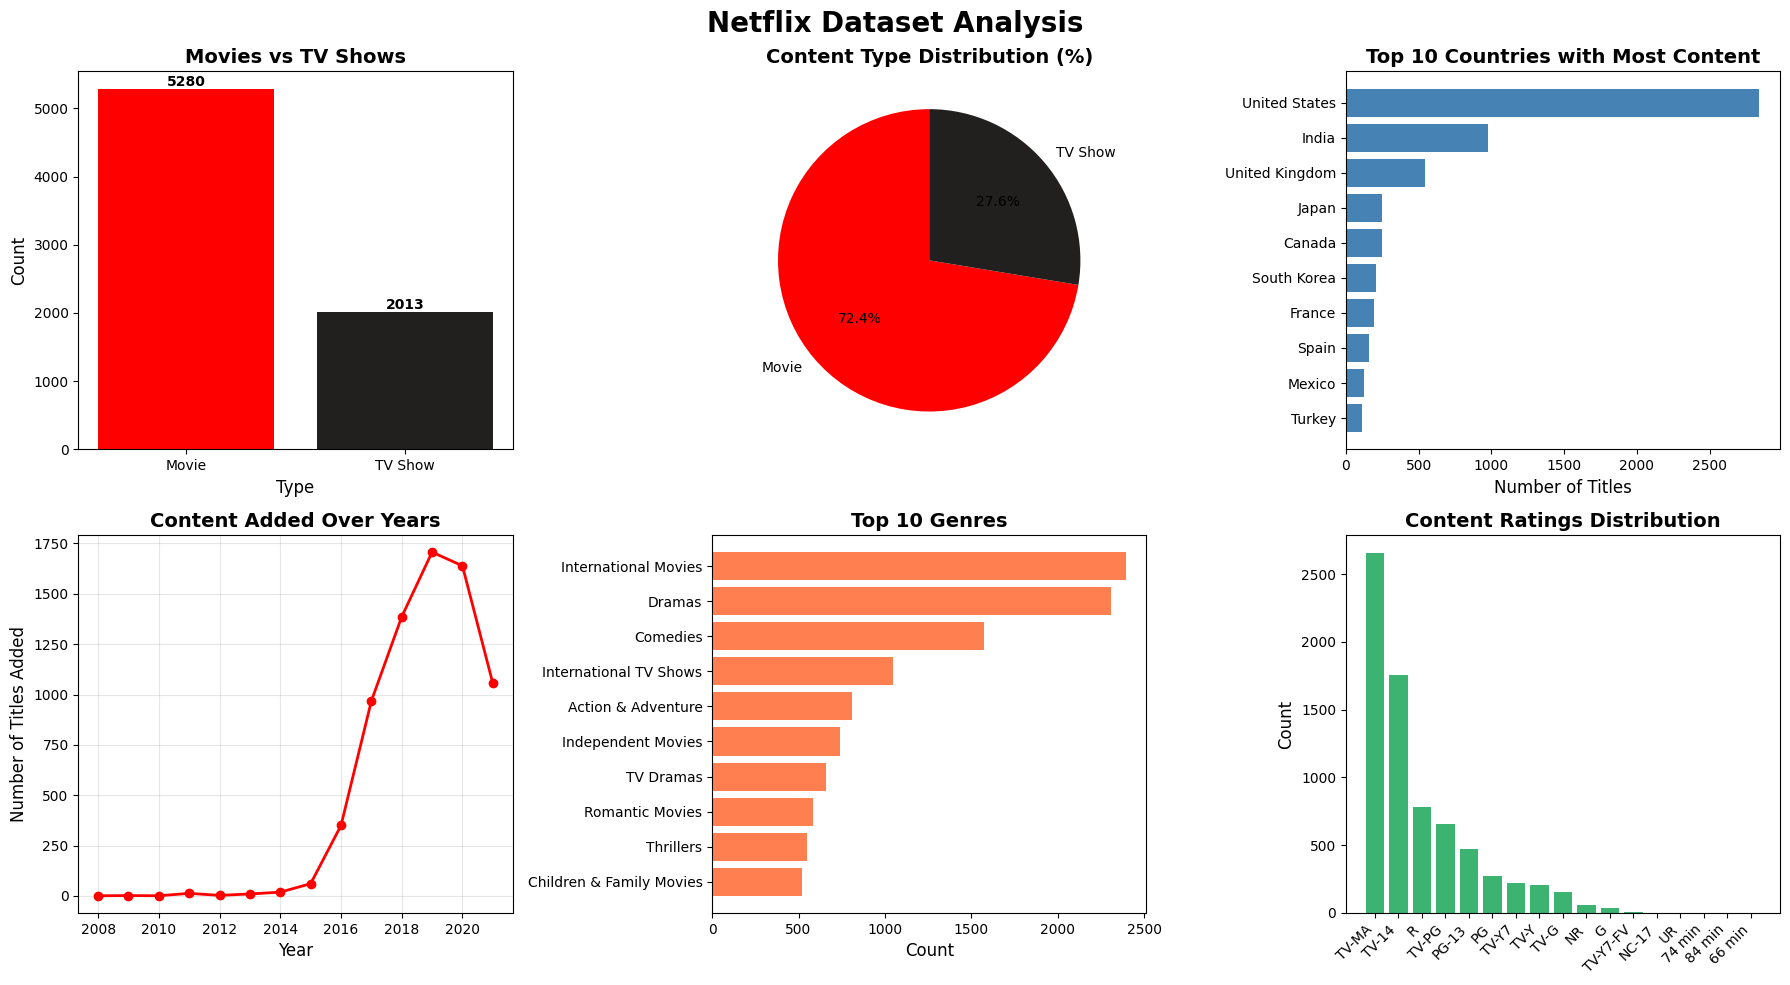

✅ All 6 charts created successfully!


In [ ]:
# Set up the style
plt.style.use('default')
sns.set_palette("husl")

# Create a figure with 6 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Netflix Dataset Analysis', fontsize=20, fontweight='bold')

# ============ CHART 1: Bar Chart - Movies vs TV Shows ============
ax = axes[0, 0]
type_counts = df_clean['type'].value_counts()
ax.bar(type_counts.index, type_counts.values, color=['#FF0000', '#221F1F'])
ax.set_title('Movies vs TV Shows', fontsize=14, fontweight='bold')
ax.set_ylabel('Count', fontsize=12)
ax.set_xlabel('Type', fontsize=12)
for i, v in enumerate(type_counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')

# ============ CHART 2: Pie Chart - Content Type Distribution ============
ax = axes[0, 1]
ax.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
       colors=['#FF0000', '#221F1F'], startangle=90)
ax.set_title('Content Type Distribution (%)', fontsize=14, fontweight='bold')

# ============ CHART 3: Bar Chart - Top 10 Countries ============
ax = axes[0, 2]
top_countries = df_clean['first_country'].value_counts().head(10)
ax.barh(range(len(top_countries)), top_countries.values, color='steelblue')
ax.set_yticks(range(len(top_countries)))
ax.set_yticklabels(top_countries.index)
ax.set_title('Top 10 Countries with Most Content', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Titles', fontsize=12)
ax.invert_yaxis()

# ============ CHART 4: Line Chart - Content Added Over Years ============
ax = axes[1, 0]
yearly_data = df_clean['year_added'].value_counts().sort_index()
ax.plot(yearly_data.index, yearly_data.values, marker='o', linewidth=2, markersize=6, color='#FF0000')
ax.set_title('Content Added Over Years', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Titles Added', fontsize=12)
ax.grid(True, alpha=0.3)

# ============ CHART 5: Bar Chart - Top 10 Genres ============
ax = axes[1, 1]
genres = df_clean['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)
ax.barh(range(len(top_genres)), top_genres.values, color='coral')
ax.set_yticks(range(len(top_genres)))
ax.set_yticklabels(top_genres.index, fontsize=10)
ax.set_title('Top 10 Genres', fontsize=14, fontweight='bold')
ax.set_xlabel('Count', fontsize=12)
ax.invert_yaxis()

# ============ CHART 6: Bar Chart - Content Ratings ============
ax = axes[1, 2]
ratings = df_clean['rating'].value_counts()
ax.bar(range(len(ratings)), ratings.values, color='mediumseagreen')
ax.set_xticks(range(len(ratings)))
ax.set_xticklabels(ratings.index, rotation=45, ha='right')
ax.set_title('Content Ratings Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Count', fontsize=12)

# Adjust spacing
plt.tight_layout()
plt.show()

print("✅ All 6 charts created successfully!")

**INSIGHT 1:** Netflix's catalog is dominated by nearly [72.4%] movies and only [27.6%] TV shows. This shows Netflix prioritizes movies because people prefer shorter viewing. As a result, viewers have more variety and can watch content without committing to multiple seasons.

**INSIGHT 2:** Netflix's content is heavily focused on the USA, with [2842] titles compared to India's [976] — meaning nearly 3 times more content. This shows Netflix prioritizes the  larger market and richer audience because that's where they can earn more revenue. Other countries get less investment in content production.

**INSIGHT 3:** Netflix added the most content in 2019 with peak production, but content additions dipped after 2019. This suggests that the COVID-19 pandemic starting in 2020 disrupted film and TV production worldwide, causing Netflix to add fewer new titles. This shows how external events impact Netflix's ability to grow its library.

**INSIGHT 4:** International Movies is the #1 genre with 2,392 titles, far more than any other genre. This shows Netflix's strategy to reach audiences worldwide beyond just English speakers and expand into growing markets like India, Latin America, and Asia. By investing heavily in international content, Netflix can compete globally and attract viewers from different cultures and languages.

**INSIGHT 5:** TV-MA rated content dominates Netflix with 2,657 titles, making it the most common rating. This shows Netflix's strategy to target adult viewers who have more disposable income to pay for subscriptions, and also because adult-oriented content like dramas and action shows are highly engaging and popular. Netflix prioritizes mature audiences over family-friendly content, indicating their core market is adults, not children.

# MOST SUPRSING FINDING
I was surprised by three things: First, the huge gap between USA (2842 titles) and India (976 titles) showed how much Netflix prioritizes wealthy markets. Second, TV-MA is the top rating, not R-rated content, which means Netflix really targets mature adult audiences for profit. Third, Drama being the second most popular genre after International Movies reveals that Netflix focuses on serious, engaging storytelling rather than light entertainment. Together, these findings show Netflix is a business targeting affluent adults globally, not a family entertainment platform